<a href="https://colab.research.google.com/github/mvgolubev99/kaggle-chemical-structure-and-logp/blob/dev/logp_baseline_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# download data, resulting .csv file saved as '/content/logP_dataset.csv'
!curl -L -o /content/archive_logp.zip https://www.kaggle.com/api/v1/datasets/download/matthewmasters/chemical-structure-and-logp
!unzip /content/archive_logp.zip -d /content/
!rm /content/archive_logp.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 81468  100 81468    0     0  74860      0  0:00:01  0:00:01 --:--:--  997k
Archive:  /content/archive_logp.zip
  inflating: /content/logP_dataset.csv  


In [ ]:
!pip install rdkit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 49.5 MB/s eta 0:00:00


I generated it using ChatGPT

In [ ]:
# %%
"""
Notebook: logP model comparison (random split and Butina split)
Designed for Google Colab. Generates fingerprints, runs k-fold CV on train_,
performs grid-search over representations and models, saves parity plots and
summary table of mean & std RMSE (cross-validation). Test set is held-out and
not touched during CV.

Requirements (Colab):
!pip install rdkit-pypi lightgbm scikit-learn matplotlib pandas joblib

Usage: run cells in order. Default k=5, random_state=42.
"""

# %%
# Basic imports and environment setup
import os
import math
import random
from collections import defaultdict
from dataclasses import dataclass
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# scikit-learn
from sklearn.model_selection import KFold, train_test_split
from sklearn.linear_model import Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# lightgbm
from lightgbm import LGBMRegressor

# RDKit (fingerprints, butina)
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.DataStructs import ExplicitBitVect
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina

# For saving models/plots
from joblib import dump

# Create output directory
OUTDIR = 'results'
os.makedirs(OUTDIR, exist_ok=True)

In [ ]:
# %%
# ----------------------------- Utilities ----------------------------------

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

set_seed(42)


def rmse(y_true, y_pred):
    return float(math.sqrt(mean_squared_error(y_true, y_pred)))


def ensure_mol(smiles: str):
    m = Chem.MolFromSmiles(smiles)
    if m is None:
        raise ValueError(f"Invalid SMILES: {smiles}")
    return m

# %%
# ---------------------- Representation adapters --------------------------
class RepresentationAdapter:
    """Base class for chemical representations. Implement `fit_transform` and
    `transform` to be compatible with the pipeline. Returns numpy arrays.
    """
    def fit(self, smiles_list: List[str]):
        # optional precomputation
        return self

    def fit_transform(self, smiles_list: List[str]) -> np.ndarray:
        self.fit(smiles_list)
        return self.transform(smiles_list)

    def transform(self, smiles_list: List[str]) -> np.ndarray:
        raise NotImplementedError


@dataclass
class MorganAdapter(RepresentationAdapter):
    radius: int = 2
    n_bits: int = 2048
    use_features: bool = False  # False -> ECFP, True -> FCFP

    def transform(self, smiles_list: List[str]) -> np.ndarray:
        arr = []
        for s in smiles_list:
            m = Chem.MolFromSmiles(s)
            if m is None:
                # represent invalid as zero vector
                vec = np.zeros(self.n_bits, dtype=int)
            else:
                bv = GetMorganFingerprintAsBitVect(m, self.radius, nBits=self.n_bits,
                                                   useFeatures=self.use_features)
                a = np.zeros((self.n_bits,), dtype=int)
                DataStructs.ConvertToNumpyArray(bv, a)
                vec = a.astype(int)
            arr.append(vec)
        return np.vstack(arr)


@dataclass
class MACCSAdapter(RepresentationAdapter):
    def transform(self, smiles_list: List[str]) -> np.ndarray:
        arr = []
        for s in smiles_list:
            m = Chem.MolFromSmiles(s)
            if m is None:
                vec = np.zeros((167,), dtype=int)
            else:
                bv = rdMolDescriptors.GetMACCSKeysFingerprint(m)
                a = np.zeros((167,), dtype=int)
                DataStructs.ConvertToNumpyArray(bv, a)
                vec = a.astype(int)
            arr.append(vec)
        return np.vstack(arr)

# Factory to easily get adapters by name
REPRESENTATIONS = {
    'ECFP': lambda: MorganAdapter(radius=2, n_bits=2048, use_features=False),
    'FCFP': lambda: MorganAdapter(radius=2, n_bits=2048, use_features=True),
    'MACCS': lambda: MACCSAdapter(),
}

# %%
# --------------------------- Model adapters -------------------------------
class ModelAdapter:
    def __init__(self, model: Any):
        self.model = model

    def fit(self, X, y):
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X)


def make_model(name: str, random_state: int = 42):
    """Return a sklearn-like estimator (with .fit/.predict). Linear models are
    wrapped in a pipeline with StandardScaler.
    """
    if name == 'LASSO':
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('est', Lasso(alpha=1.0, random_state=random_state, max_iter=10000))
        ])
        return pipe
    if name == 'RIDGE':
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('est', Ridge(alpha=1.0, random_state=random_state, max_iter=10000))
        ])
        return pipe
    if name == 'RF':
        return RandomForestRegressor(random_state=random_state)
    if name == 'LGBM':
        return LGBMRegressor(random_state=random_state)
    raise ValueError(f'Unknown model: {name}')

MODELS = ['LASSO', 'RIDGE', 'RF', 'LGBM']

# %%
# --------------------------- Butina split --------------------------------
def butina_split(smiles: List[str], test_frac: float = 0.2, cutoff: float = 0.6, seed: int = 42
                 ) -> Tuple[List[int], List[int]]:
    """
    Create a train/test split based on Butina clustering of Morgan fingerprints
    using Tanimoto similarity. Clusters are randomly assigned to test until the
    desired test fraction is reached. Returns indices (train_idx, test_idx).
    """
    set_seed(seed)
    fps = []
    for s in smiles:
        m = Chem.MolFromSmiles(s)
        if m is None:
            fps.append(DataStructs.ExplicitBitVect(2048))
        else:
            fps.append(GetMorganFingerprintAsBitVect(m, 2, nBits=2048))

    n = len(fps)
    if n == 0:
        return [], []

    dists = []
    for i in range(n - 1):
        sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[i + 1:])
        for s in sims:
            dists.append(1.0 - s)

    clusters = Butina.ClusterData(dists, n, cutoff, isDistData=True)
    cluster_list = list(clusters)
    random.shuffle(cluster_list)

    test_idx = []
    cum = 0
    target = int(math.floor(test_frac * n))
    for cl in cluster_list:
        if cum >= target:
            break
        test_idx.extend(cl)
        cum = len(test_idx)

    train_idx = [i for i in range(n) if i not in test_idx]
    return train_idx, test_idx

# %%
# --------------------------- Data loading --------------------------------
def download_and_load(filepath: str = '/content/logP_dataset.csv') -> pd.DataFrame:
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"File not found: {filepath}. Please download the dataset to this path in Colab first.")
    df = pd.read_csv(filepath, names=['smiles', 'logp'])
    df = df.dropna().reset_index(drop=True)
    return df

# %%
# --------------------------- Cross-validation ----------------------------
def kfold_indices(n_samples: int, k: int = 5, seed: int = 42):
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    for train_idx, val_idx in kf.split(range(n_samples)):
        yield train_idx, val_idx


def evaluate_rep_model_cv(X: np.ndarray, y: np.ndarray, model_name: str, k: int = 5, seed: int = 42,
                          prefix: str = 'run') -> Tuple[float, float, List[float]]:
    fold_rmses = []
    preds_all = []
    y_all = []

    n = X.shape[0]
    for fold, (tr, val) in enumerate(kfold_indices(n, k, seed), start=1):
        X_tr, y_tr = X[tr], y[tr]
        X_val, y_val = X[val], y[val]

        model = make_model(model_name, random_state=seed)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)

        fold_rmse = rmse(y_val, y_pred)
        fold_rmses.append(fold_rmse)

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.scatter(y_val, y_pred)
        ax.set_xlabel('y_true')
        ax.set_ylabel('y_pred')
        ax.set_title(f'Parity plot: {prefix} {model_name} fold {fold} RMSE={fold_rmse:.4f}')
        vmax = max(max(y_val), max(y_pred))
        vmin = min(min(y_val), min(y_pred))
        ax.plot([vmin, vmax], [vmin, vmax], linestyle='--')
        fname = os.path.join(OUTDIR, f'{prefix}_{model_name}_fold{fold}_parity.png')
        fig.savefig(fname, bbox_inches='tight')
        plt.close(fig)

        preds_all.extend(y_pred.tolist())
        y_all.extend(y_val.tolist())

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_all, preds_all)
    ax.set_xlabel('y_true')
    ax.set_ylabel('y_pred')
    ax.set_title(f'Parity plot: {prefix} {model_name} all folds')
    vmin = min(min(y_all), min(preds_all))
    vmax = max(max(y_all), max(preds_all))
    ax.plot([vmin, vmax], [vmin, vmax], linestyle='--')
    fname = os.path.join(OUTDIR, f'{prefix}_{model_name}_allfolds_parity.png')
    fig.savefig(fname, bbox_inches='tight')
    plt.close(fig)

    mean_rmse = float(np.mean(fold_rmses))
    std_rmse = float(np.std(fold_rmses, ddof=1)) if len(fold_rmses) > 1 else 0.0
    return mean_rmse, std_rmse, fold_rmses

# %%
# --------------------------- Grid search loop ----------------------------
def grid_search_cv(df: pd.DataFrame,
                   split_method: str = 'random',
                   test_size: float = 0.2,
                   k: int = 5,
                   random_state: int = 42,
                   butina_cutoff: float = 0.6) -> pd.DataFrame:
    set_seed(random_state)

    smiles = df['smiles'].tolist()
    y = df['logp'].values

    if split_method == 'random':
        idx_all = list(range(len(smiles)))
        train_idx, test_idx = train_test_split(idx_all, test_size=test_size, random_state=random_state)
    elif split_method == 'butina':
        train_idx, test_idx = butina_split(smiles, test_frac=test_size, cutoff=butina_cutoff, seed=random_state)
    else:
        raise ValueError('Unknown split method')

    df_train = df.iloc[train_idx].reset_index(drop=True)
    df_test = df.iloc[test_idx].reset_index(drop=True)

    results = []

    for rep_name, rep_factory in REPRESENTATIONS.items():
        print(f'Computing representation: {rep_name}...')
        rep = rep_factory()
        X_train = rep.fit_transform(df_train['smiles'].tolist())
        y_train = df_train['logp'].values

        rep_path = os.path.join(OUTDIR, f'{split_method}_{rep_name}_Xtrain.npy')
        np.save(rep_path, X_train)

        for model_name in MODELS:
            print(f'Running CV: split={split_method} rep={rep_name} model={model_name}')
            prefix = f'{split_method}_{rep_name}'
            mean_rmse, std_rmse, fold_rmses = evaluate_rep_model_cv(X_train, y_train, model_name, k=k,
                                                                     seed=random_state, prefix=prefix)
            results.append({
                'split_method': split_method,
                'representation': rep_name,
                'model': model_name,
                'mean_rmse': mean_rmse,
                'std_rmse': std_rmse,
                'fold_rmses': fold_rmses,
                'n_train': len(train_idx),
                'n_test': len(test_idx),
            })

    results_df = pd.DataFrame(results).sort_values(['mean_rmse'])
    return results_df, df_train, df_test


In [ ]:
# %%
# --------------------------- Example run ---------------------------------
f = '/content/logP_dataset.csv'
print('Loading data from', f)
df = download_and_load(f)
print('Total examples:', len(df))

all_results = []
for split in ['random', 'butina']:
    print('\n--- Running pipeline for split:', split)
    res_df, df_tr, df_te = grid_search_cv(df, split_method=split, test_size=0.2, k=5, random_state=42,
                                            butina_cutoff=0.6)
    res_df.to_csv(os.path.join(OUTDIR, f'results_{split}.csv'), index=False)
    all_results.append(res_df)

summary = pd.concat(all_results, ignore_index=True)
summary = summary.sort_values(['split_method', 'mean_rmse'])
summary.to_csv(os.path.join(OUTDIR, 'summary_all.csv'), index=False)

Output of this ^ cell is too long because of too much 'DEPRECATION WARNING: please use MorganGenerator' warnings

In [6]:
print('\nSummary (top rows):')
print(summary[['split_method', 'representation', 'model', 'mean_rmse', 'std_rmse']])

summary_table = summary[['split_method', 'representation', 'model', 'mean_rmse', 'std_rmse']]
summary_table.to_csv(os.path.join(OUTDIR, 'summary_table.csv'), index=False)

print('\nAll parity plots and saved matrices are in the results/ folder.')


Summary (top rows):
   split_method representation  model  mean_rmse  std_rmse
12       butina          MACCS   LGBM   0.333941  0.010530
13       butina          MACCS     RF   0.338042  0.008102
14       butina          MACCS  RIDGE   0.458237  0.012927
15       butina           ECFP   LGBM   0.494319  0.014050
16       butina           ECFP     RF   0.524736  0.018363
17       butina           ECFP  RIDGE   0.579052  0.013228
18       butina           FCFP   LGBM   0.785382  0.015903
19       butina           FCFP     RF   0.793216  0.024106
20       butina           FCFP  RIDGE   0.869330  0.024119
21       butina           ECFP  LASSO   1.295893  0.026200
22       butina           FCFP  LASSO   1.295893  0.026200
23       butina          MACCS  LASSO   1.295893  0.026200
0        random          MACCS   LGBM   0.331487  0.006655
1        random          MACCS     RF   0.337802  0.006644
2        random          MACCS  RIDGE   0.457390  0.008552
3        random           ECFP   LG

comparison of butina and random split methods:

In [27]:
print(summary.sort_values(['representation', 'model', 'split_method'])[['split_method','representation', 'model', 'mean_rmse', 'std_rmse']])

   split_method representation  model  mean_rmse  std_rmse
21       butina           ECFP  LASSO   1.295893  0.026200
9        random           ECFP  LASSO   1.297934  0.015200
15       butina           ECFP   LGBM   0.494319  0.014050
3        random           ECFP   LGBM   0.492528  0.014683
16       butina           ECFP     RF   0.524736  0.018363
4        random           ECFP     RF   0.525350  0.011240
17       butina           ECFP  RIDGE   0.579052  0.013228
5        random           ECFP  RIDGE   0.587277  0.012745
22       butina           FCFP  LASSO   1.295893  0.026200
10       random           FCFP  LASSO   1.297934  0.015200
18       butina           FCFP   LGBM   0.785382  0.015903
6        random           FCFP   LGBM   0.786513  0.012338
19       butina           FCFP     RF   0.793216  0.024106
7        random           FCFP     RF   0.795957  0.010434
20       butina           FCFP  RIDGE   0.869330  0.024119
8        random           FCFP  RIDGE   0.861242  0.0110

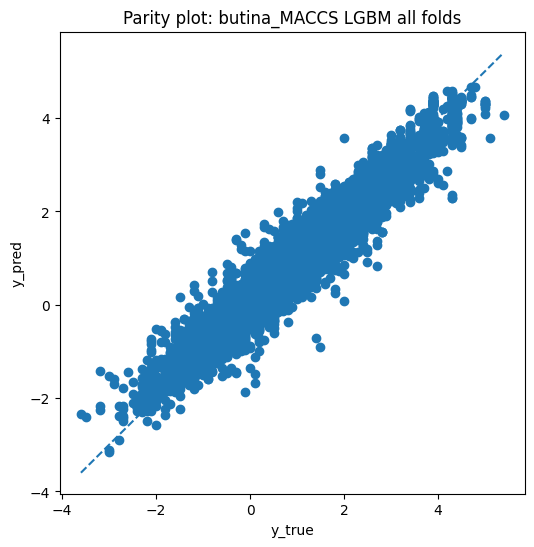

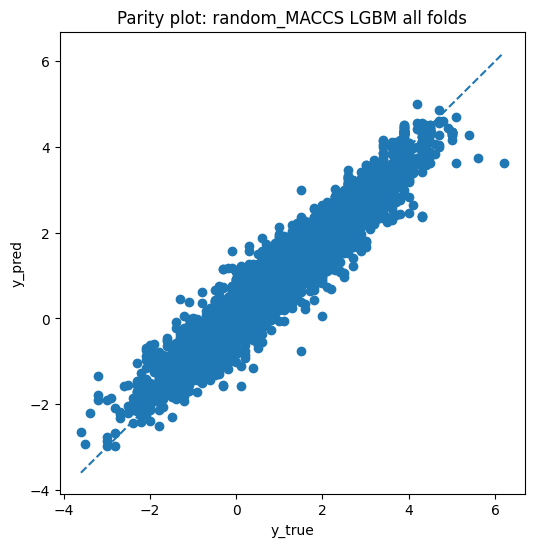

In [19]:
from IPython.display import Image, display

image_paths = [
    '/content/results/butina_MACCS_LGBM_allfolds_parity.png',
    '/content/results/random_MACCS_LGBM_allfolds_parity.png'
]

for path in image_paths:
    try:
        display(Image(filename=path))
    except FileNotFoundError:
        print(f"Image not found at: {path}")